In [ ]:
# ─────────────────────────────────────────────
# Lightning_ChangeViT Inference & Visualization
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from torchvision import transforms
from Lightning_ChangeViT import LightningModel

# ────────── 1. 설정 ──────────────────────────────────
CKPT_PATH  = "./checkpoints/changevit/20260419_vit16_resnet34_best.pth"
# CKPT_PATH  = "./checkpoints/changevit/20260417_vit16_resnet18_best.pth"
DATA_ROOT  = Path("D:/Project-Dataset/LEVIR-CD-256")
SPLIT      = "test"
IMG_SIZE   = 256
THRESHOLD  = 0.5


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ────────── 2. Load Model with Config ───────────────────────
CFG = dict(
    data_root    = "D:/Project-Dataset/LEVIR-CD-256",
    img_size     = IMG_SIZE,
    batch_size   = 16,
    num_workers  = 0,
    max_epochs   = 180,
    lr           = 2e-4,
    weight_decay = 1e-4,
    backbone     = 'vit_small_patch16_dinov3.lvd1689m',   # timm 
    # backbone     = "vit_small_patch14_dinov2.lvd142m",  # timm model
    log_dir      = "logs/changevit",
    ckpt_base    = "checkpoints/changevit",   # 실험별 서브폴더 여기 아래 생성됨
)

model = LightningModel.load_from_checkpoint(
    CKPT_PATH,
    cfg = CFG,          # save_hyperparameters() 가 되어 있으면 생략 가능
    map_location = DEVICE,
)
model.eval().to(DEVICE)
print("Model loaded ✅")


Device: cuda
Model loaded ✅


In [2]:
# ────────── 3. 전처리 transform (학습과 동일) ─────────
img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

def denormalize(tensor: torch.Tensor) -> np.ndarray:
    """[3,H,W] normalized tensor → [H,W,3] uint8 numpy for display"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img  = tensor.cpu() * std + mean          # [3,H,W]
    img  = img.clamp(0, 1).permute(1,2,0).numpy()
    return (img * 255).astype(np.uint8)

In [3]:
# ─── 4. 단일 샘플 추론 함수 ────────────────────
@torch.no_grad()
def run_inference(fname: str):
    dir_a     = DATA_ROOT / SPLIT / "A"
    dir_b     = DATA_ROOT / SPLIT / "B"
    dir_label = DATA_ROOT / SPLIT / "label"

    img_a  = Image.open(dir_a     / fname).convert("RGB")
    img_b  = Image.open(dir_b     / fname).convert("RGB")
    mask   = Image.open(dir_label / fname).convert("L")

    t_a    = img_transform(img_a)                   # [3,H,W]
    t_b    = img_transform(img_b)                   # [3,H,W]
    image  = torch.stack([t_a, t_b], dim=0)         # [2,3,H,W]
    image  = image.unsqueeze(0).to(DEVICE)          # [1,2,3,H,W]

    logits = model.model(image)                     # [1,1,H,W]
    prob   = torch.sigmoid(logits).squeeze()        # [H,W]
    pred   = (prob > THRESHOLD).cpu().numpy()       # [H,W] bool

    # GT mask: 0/255 → 0/1
    mask_np = np.array( mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST) )
    gt = (mask_np > 127).astype(np.uint8)

    # 지표 계산
    tp = ((pred == 1) & (gt == 1)).sum()
    fp = ((pred == 1) & (gt == 0)).sum()
    fn = ((pred == 0) & (gt == 1)).sum()
    precision = tp / (tp + fp + 1e-5)
    recall    = tp / (tp + fn + 1e-5)
    f1  = 2 * precision * recall / (precision + recall + 1e-5)
    iou = tp / (tp + fp + fn + 1e-5)

    return { "fname"   : fname,
             "img_a"   : denormalize(t_a),    # [H,W,3] uint8
             "img_b"   : denormalize(t_b),    # [H,W,3] uint8
             "gt"      : gt,                  # [H,W] 0/1
             "pred"    : pred.astype(np.uint8),
             "prob"    : prob.cpu().numpy(),  # [H,W] float
             "f1"      : f1,
             "iou"     : iou, }



In [7]:
# ─── 5. 5개 추론 실행 ──────────────────────────
# 수동으로 5개 파일명 지정
SELECTED_FILES = [
    "test_2_1.png",
    "test_3_1.png",
    "test_2_2.png",
    "test_7_13.png",
    "test_12_10.png",
]

results = [run_inference(f) for f in SELECTED_FILES]
print(f"{len(results)}개 추론 완료 ✅")

5개 추론 완료 ✅


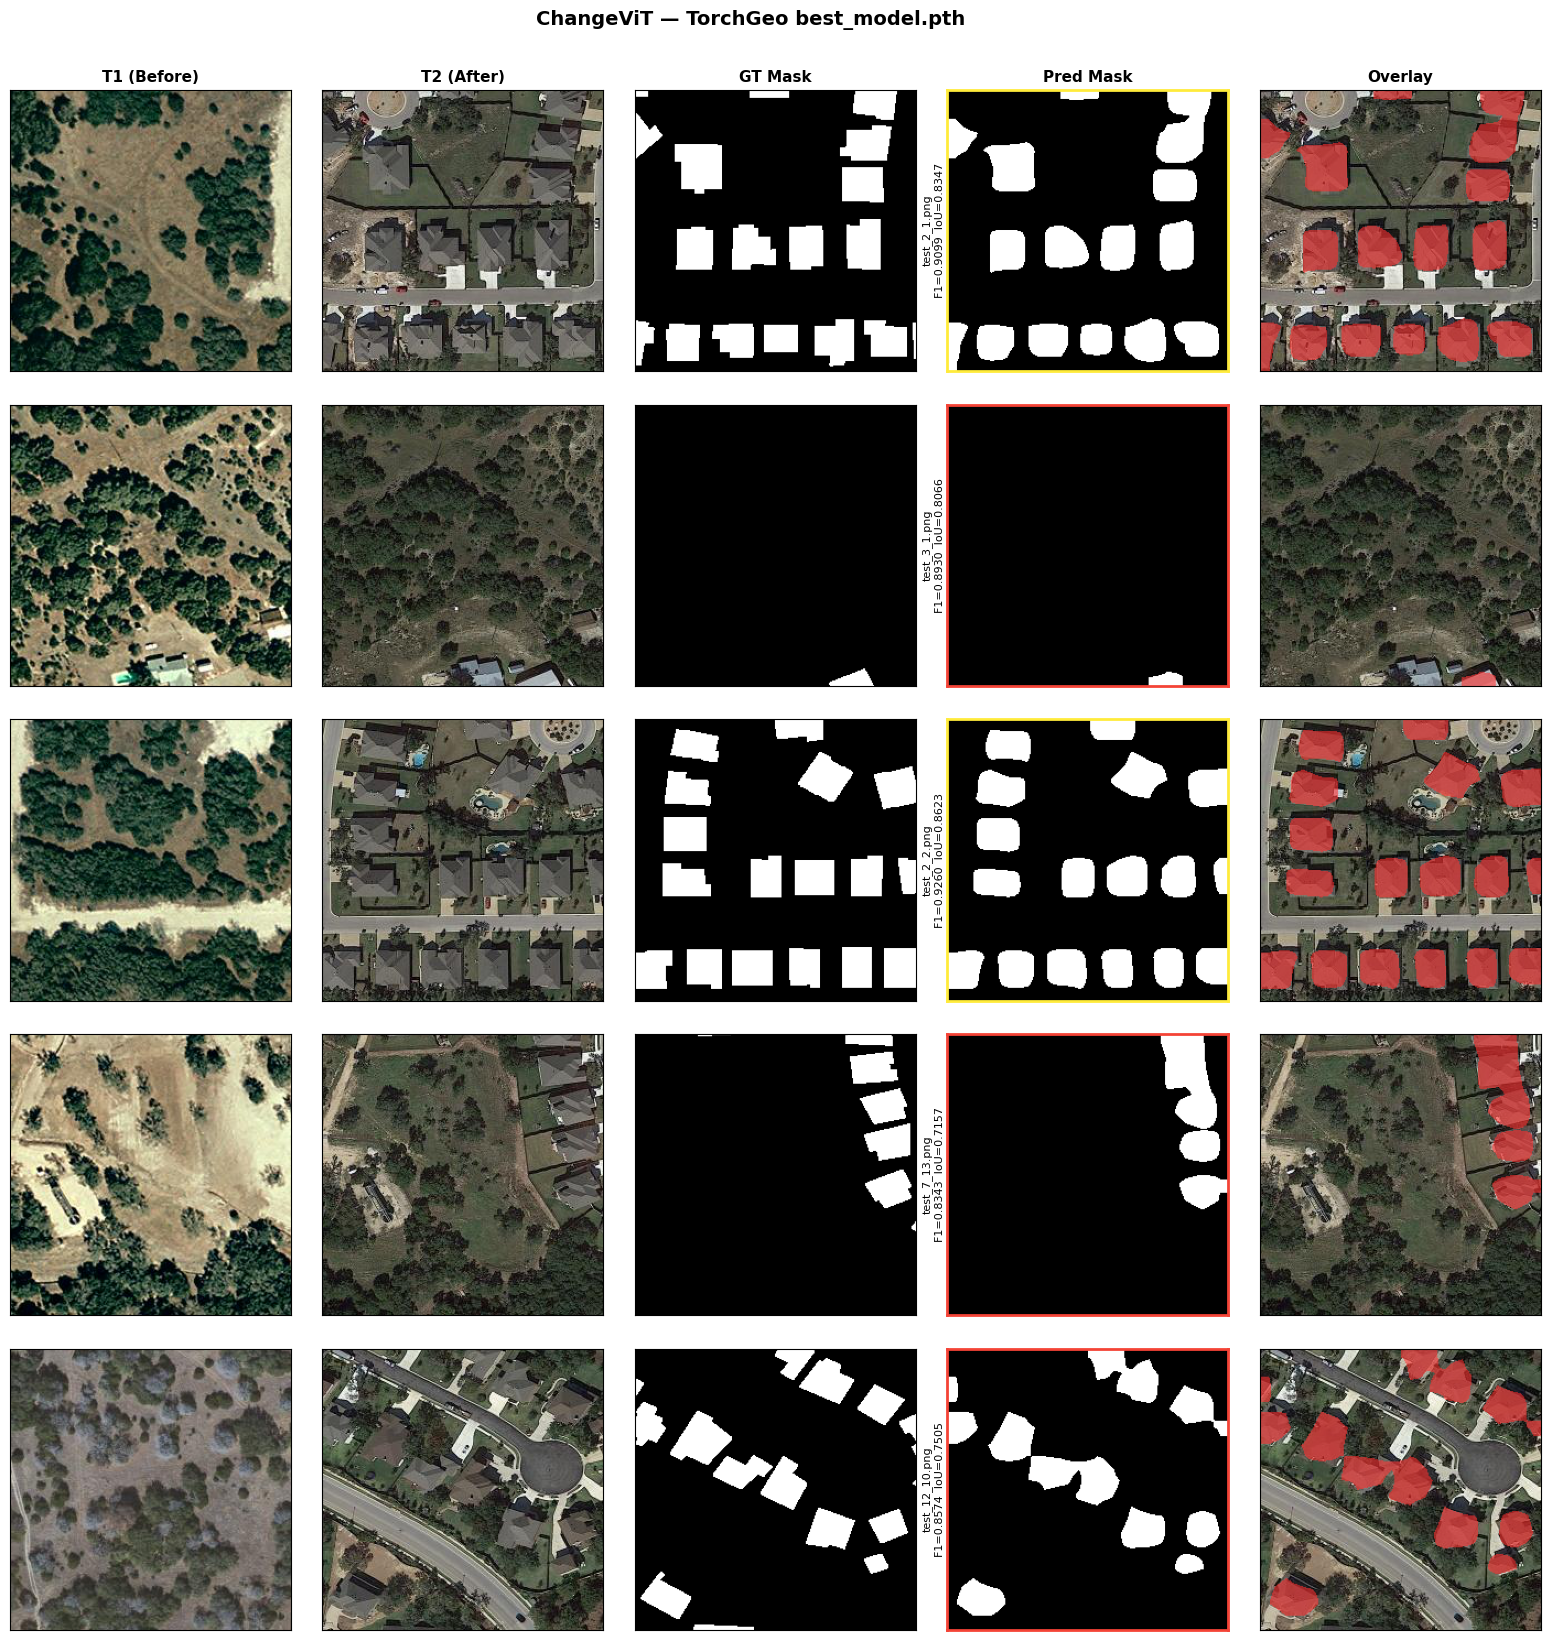

저장 완료: inference_TorchGeo_results.png


In [10]:
# ─── 6. 시각화 ─────────────────────────────────
# 레이아웃: 행=파일 5개, 열=T1 / T2 / GT / Pred / Overlay
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

COL_TITLES = ["T1 (Before)", "T2 (After)", "GT Mask", "Pred Mask", "Overlay"]
N = len(results)

fig = plt.figure(figsize=(20, 4 * N))
# fig.patch.set_facecolor("#0f0f0f")
outer = gridspec.GridSpec(N, 1, hspace=0.12, figure=fig)

for row_idx, r in enumerate(results):
    inner = gridspec.GridSpecFromSubplotSpec( 1, 5, subplot_spec=outer[row_idx], wspace=0.04 )

    # Overlay: T2 위에 pred 반투명 빨간색
    overlay = r["img_b"].copy()
    change_mask = r["pred"].astype(bool)
    overlay[change_mask] = (
        overlay[change_mask] * 0.4 +
        np.array([255, 50, 50]) * 0.6
    ).astype(np.uint8)

    images = [r["img_a"], r["img_b"], r["gt"], r["pred"], overlay]
    cmaps  = [None,        None,       "gray",  "gray",   None   ]

    for col_idx, (img, cmap) in enumerate(zip(images, cmaps)):
        ax = fig.add_subplot(inner[col_idx])
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1 if img.max() <= 1 else None)
        ax.set_xticks([]); ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx],
                         color='black', fontsize=11, pad=6, fontweight="bold")

        if col_idx == 3:
            label = (f"{r['fname']}\n"
                     f"F1={r['f1']:.4f}  IoU={r['iou']:.4f}")
            ax.set_ylabel(label, color='black', fontsize=8,
                          rotation=90, labelpad=10, va="center")

        if col_idx == 3:  # Pred 열: F1 기반 테두리 색
            color = ("#00e676" if r["f1"] >= 0.93 else
                     "#ffeb3b" if r["f1"] >= 0.90 else "#f44336")
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2)

plt.suptitle("ChangeViT — TorchGeo best_model.pth",
             color="black", fontsize=14, fontweight="bold", y=0.920)
plt.savefig("Inference_TorchGeo_results.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("저장 완료: inference_TorchGeo_results.png")

# %%
# # 1. Delete the model and optimizer
# del model
# # del trainer  # If you created a Trainer instance
# # 2. Force Python to clean up
# gc.collect()
# # 3. Clear GPU cache
# torch.cuda.empty_cache()